In [1]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-qtm_o6t_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-qtm_o6t_
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b8cfcd06902d0b08e88b3c92a3c547431cc6dbfc1fd5cbaf5a1922cf11a26716
  Stored in directory: /tmp/pip-ephem-wheel-cache-o0vbn6sj/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [4]:
import clip

In [5]:
# load CLIP
model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 98.6MiB/s]


In [6]:
preprocess.transforms

[Resize(size=224, interpolation=bicubic, max_size=None, antialias=True),
 CenterCrop(size=(224, 224)),
 <function clip.clip._convert_image_to_rgb(image)>,
 ToTensor(),
 Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))]

In [7]:
preprocessing = transforms.Compose([
    transforms.ToTensor(),
    preprocess.transforms[0],
    preprocess.transforms[-1]
])

In [8]:
# COCO labels
labels = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog",
    "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
    "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
    "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle",
    "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich",
    "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

In [9]:
texts = clip.tokenize(labels).to(device)
print(texts.shape)

torch.Size([80, 77])


In [10]:
!pip install fastncut

In [11]:
from fastncut import Ncut

In [12]:
# load NCut, CLIP requires fixing its features with a suitable extension
fastncut = Ncut(data_format="bhwc",auto_fix=True).to(device)

In [13]:
!wget https://www.agentspace.org/download/chicken-dog.png

--2026-03-29 09:45:24--  https://www.agentspace.org/download/chicken-dog.png
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1540 (1.5K) [image/png]
Saving to: ‘chicken-dog.png’

chicken-dog.png     100%[===================>]   1.50K  --.-KB/s    in 0s      

2026-03-29 09:45:25 (780 MB/s) - ‘chicken-dog.png’ saved [1540/1540]



In [14]:
# load image
image = cv2.imread("chicken-dog.png")
print(image.shape)

(240, 240, 3)


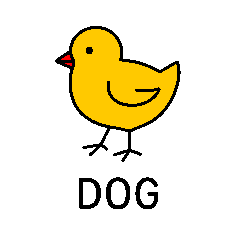

In [15]:
cv2_imshow(image)

In [16]:
# call CLIP to name the image
def nameIt(image):
    blob = preprocessing(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(device) # 1 x 3 x 224 x 224
    with torch.no_grad():
        logits_per_image, logits_per_text = model(blob, texts) # 1 x 3 x 224 x 224, 80 x 77 -> 1 x 80, 80 x 1
        probs = logits_per_image.softmax(dim=-1)[0].cpu().numpy()
    top5 = np.argsort(probs)[-5:][::-1]
    print([f'{labels[index]}:{probs[index]:.2f}' for index in top5])

In [17]:
# name the image
nameIt(image)

['dog:0.92', 'bird:0.07', 'hot dog:0.01', 'cup:0.00', 'person:0.00']


In [18]:
# call again CLIP on the image, but in details to get features 7x7x768
blob = preprocessing(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(device) # 1 x 3 x 224 x 224
x = blob.type(model.dtype) # shape ... [1, 3, 224, 224]
x = model.visual.conv1(x)  # shape = [*, width, grid, grid]  ... [1, 768, 7, 7]
x = x.reshape(x.shape[0], x.shape[1], -1)  # shape = [*, width, grid ** 2] ... [1, 768, 49]
x = x.permute(0, 2, 1)  # shape = [*, grid ** 2, width] ... [1, 49, 768]
x = torch.cat([model.visual.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device), x], dim=1)  # shape = [*, grid ** 2 + 1, width] add CLS [1, 50, 768]
x = x + model.visual.positional_embedding.to(x.dtype) # add positional encoding [1, 50, 768]
x = model.visual.ln_pre(x) # [1, 50, 768]
x = x.permute(1, 0, 2)  # NLD -> LND   [50, 1, 768]
x = model.visual.transformer(x) # [50, 1, 768]
x = x.permute(1, 0, 2) # [1, 50, 768]
feats = x[:,1:,:].reshape(1,7,7,768)
print(feats.shape)

torch.Size([1, 7, 7, 768])


In [19]:
# interpolate features
feats = F.interpolate(feats.permute(0, 3, 1, 2), size=image.shape[:2], mode='bilinear', align_corners=False).permute(0, 2, 3, 1)
print(feats.shape)

torch.Size([1, 240, 240, 768])


In [20]:
feats = feats.float() # 16bits -> 32bits

(240, 240)


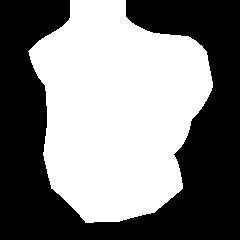

In [21]:
# 1st NCut, image -> no-info : base
bipartition = fastncut(feats)[0]
base = bipartition.detach().cpu().numpy().astype(np.uint8)*255
print(base.shape)
cv2_imshow(base)

(240, 240)


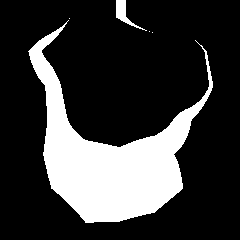

In [22]:
# 2nd NCut, base -> bird : dog
bipartition2 = fastncut(feats,mask=bipartition)[0]
mask = bipartition2.detach().cpu().numpy().astype(np.uint8)*255
print(mask.shape)
cv2_imshow(mask)

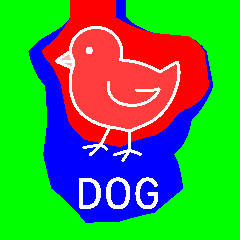

In [23]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
disp = cv2.merge([base&mask|~gray,~base|~gray,base&~mask|~gray])
cv2_imshow(disp)

In [24]:
def tri(mask):
    return cv2.merge([mask,mask,mask])

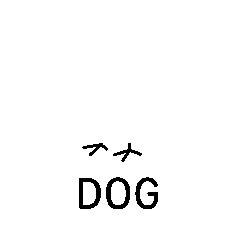

In [25]:
image1 = image | ~tri(base) | ~tri(mask)
cv2_imshow(image1)

In [26]:
nameIt(image1)

['dog:0.97', 'hot dog:0.01', 'person:0.00', 'keyboard:0.00', 'horse:0.00']


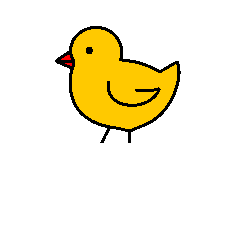

In [27]:
image2 = image | ~tri(base) | tri(mask)
cv2_imshow(image2)

In [28]:
nameIt(image2)

['bird:0.92', 'cup:0.01', 'dog:0.01', 'mouse:0.00', 'banana:0.00']
